In [9]:
#2021.08.18. WED
#Team_밥믈리에

#00. 패키지 호출
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
import warnings 

#00-1. warning message ignore 
warnings.filterwarnings(action='ignore')


In [10]:
#01. 데이터셋 호출 및 전처리하기. 
#(1) 데이터셋 불러오기
cultivar_dataset = pd.read_excel('../data/nlp/cultivar_indicator_scaling_T.xlsx')

#(2) 데이터셋의 cultivar 컬럼 인덱스로 설정하기. 
cultivar_dataset.rename(columns={'Unnamed: 0':'cultivar'}, inplace=True)
cultivar_dataset.set_index('cultivar', inplace=True)

#(3) 결과 확인하기. 
cultivar_dataset

,고소하다,고슬하다,꼬들하다,달다,딱딱하다,부드럽다,질다,쫀득하다,찰지다,촉촉하다,탱탱하다,푸석하다
cultivar,,,,,,,,,,,,
count_고시히카리,0.648148,1.000000,0.742857,0.965217,0.25000,0.629032,0.657143,1.000000,0.725000,0.927711,0.584746,0.408284
count_골드퀸,0.692593,0.020408,0.028571,0.104348,0.03125,0.016129,0.057143,0.041667,0.037500,0.036145,0.008475,0.023669
count_밀키퀸,0.003704,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.005917
count_삼광,0.477778,0.571429,0.314286,0.547826,0.40625,0.387097,0.314286,0.468750,0.453125,0.313253,0.254237,0.366864
count_새청무,0.022222,0.020408,0.000000,0.008696,0.00000,0.000000,0.028571,0.020833,0.009375,0.048193,0.008475,0.011834
count_신동진,1.000000,0.734694,1.000000,1.000000,1.00000,0.661290,0.828571,0.802083,1.000000,1.000000,1.000000,0.840237
count_영호진미,0.237037,0.367347,0.314286,0.173913,0.46875,0.403226,0.342857,0.411458,0.396875,0.265060,0.144068,0.431953
count_오대,0.311111,0.326531,0.314286,0.443478,0.34375,0.209677,0.400000,0.447917,0.415625,0.337349,0.262712,0.431953
count_일품,0.085185,0.040816,0.085714,0.060870,0.03125,0.048387,0.057143,0.057292,0.081250,0.072289,0.008475,0.076923


In [11]:
#03. k-means 모델로 군집화하기. 
#(1) k-means 모델 객체 정의하기. 
kmeans_model = DBSCAN(min_samples=2, eps=0.5)

#(2) 데이터셋에 군집 번호 컬럼 추가하기. 
cultivar_dataset['cluster_num'] = kmeans_model.fit_predict(cultivar_dataset)

#(4) 행 별 실루엣 계수 컬럼 추가하기. 
#cultivar_dataset['silhouette_coef'] = silhouette_samples(cultivar_dataset.iloc[:,:12], cultivar_dataset['cluster_num'])

#(5) 처리 결과 확인하기. 
cultivar_dataset

,고소하다,고슬하다,꼬들하다,달다,딱딱하다,부드럽다,질다,쫀득하다,찰지다,촉촉하다,탱탱하다,푸석하다,cluster_num
cultivar,,,,,,,,,,,,,
count_고시히카리,0.648148,1.000000,0.742857,0.965217,0.25000,0.629032,0.657143,1.000000,0.725000,0.927711,0.584746,0.408284,-1
count_골드퀸,0.692593,0.020408,0.028571,0.104348,0.03125,0.016129,0.057143,0.041667,0.037500,0.036145,0.008475,0.023669,-1
count_밀키퀸,0.003704,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.005917,0
count_삼광,0.477778,0.571429,0.314286,0.547826,0.40625,0.387097,0.314286,0.468750,0.453125,0.313253,0.254237,0.366864,1
count_새청무,0.022222,0.020408,0.000000,0.008696,0.00000,0.000000,0.028571,0.020833,0.009375,0.048193,0.008475,0.011834,0
count_신동진,1.000000,0.734694,1.000000,1.000000,1.00000,0.661290,0.828571,0.802083,1.000000,1.000000,1.000000,0.840237,-1
count_영호진미,0.237037,0.367347,0.314286,0.173913,0.46875,0.403226,0.342857,0.411458,0.396875,0.265060,0.144068,0.431953,1
count_오대,0.311111,0.326531,0.314286,0.443478,0.34375,0.209677,0.400000,0.447917,0.415625,0.337349,0.262712,0.431953,1
count_일품,0.085185,0.040816,0.085714,0.060870,0.03125,0.048387,0.057143,0.057292,0.081250,0.072289,0.008475,0.076923,0


In [12]:
#04. 군집 시각화하기. 
#(1) 주성분 분석을 통해 2차원으로 축소하기. 
pca = PCA(n_components=2, random_state=2021)
cultivar_dataset_pca = pca.fit_transform(cultivar_dataset.iloc[:,:-1])
cultivar_dataset_pca = pd.DataFrame(cultivar_dataset_pca, columns=['PC1','PC2'])
cultivar_dataset_pca['cluster_num'] = kmeans_model.fit_predict(cultivar_dataset_pca)
cultivar_dataset_pca

,PC1,PC2,cluster_num
0,1.581405,-0.465021,-1
1,-0.619955,-0.078634,0
2,-0.923990,-0.000146,0
3,0.484905,-0.059245,1
4,-0.874158,-0.019133,0
5,2.195319,-0.137444,-1
6,0.203592,0.195185,1
7,0.304225,0.001134,1
8,-0.720166,0.010817,0
9,-0.654052,-0.010012,0


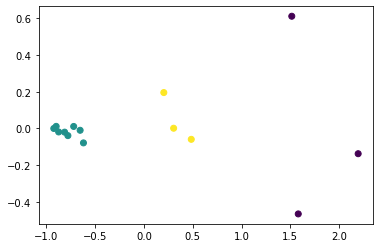

In [13]:
#(2) PCA 처리값을 기반으로 시각화하기. 
plt.scatter(x=cultivar_dataset_pca['PC1'], y=cultivar_dataset_pca['PC2'], c=cultivar_dataset_pca['cluster_num'])
plt.show()

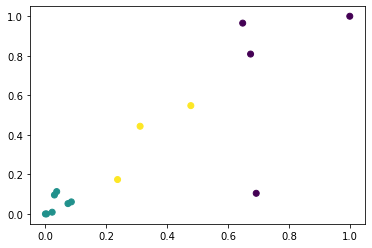

In [14]:
#05. 
#(1)
plt.scatter(x=cultivar_dataset['고소하다'], y=cultivar_dataset['달다'], c=cultivar_dataset['cluster_num'])
plt.show()

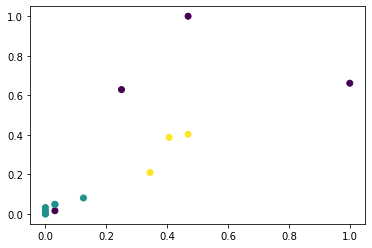

In [15]:
#(2)
plt.scatter(x=cultivar_dataset['딱딱하다'], y=cultivar_dataset['부드럽다'], c=cultivar_dataset['cluster_num'])
plt.show()